In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:/Users/HP/OneDrive/Desktop/DsIntern/iris.csv')

In [6]:
df.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
15,16,5.7,4.4,1.5,0.4,Iris-setosa
64,65,5.6,2.9,3.6,1.3,Iris-versicolor
117,118,7.7,3.8,6.7,2.2,Iris-virginica
131,132,7.9,3.8,6.4,2.0,Iris-virginica
106,107,4.9,2.5,4.5,1.7,Iris-virginica
6,7,4.6,3.4,1.4,0.3,Iris-setosa
94,95,5.6,2.7,4.2,1.3,Iris-versicolor
29,30,4.7,3.2,1.6,0.2,Iris-setosa
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
42,43,4.4,3.2,1.3,0.2,Iris-setosa


In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [10]:
df.shape

(150, 6)

In [11]:
df=df.drop(columns=['Id'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [13]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

<Axes: >

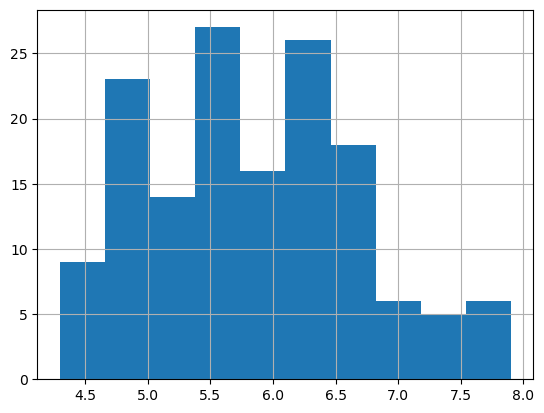

In [14]:
df['SepalLengthCm'].hist()

<Axes: >

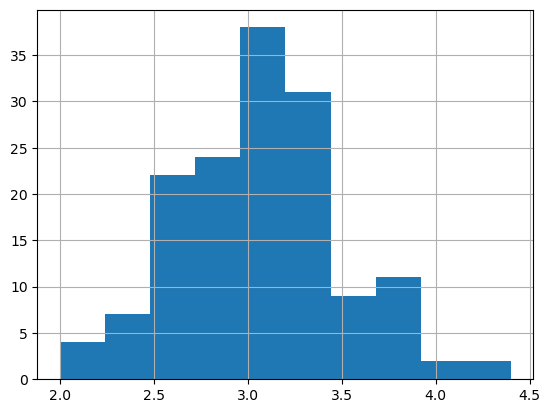

In [15]:
df['SepalWidthCm'].hist()

<Axes: >

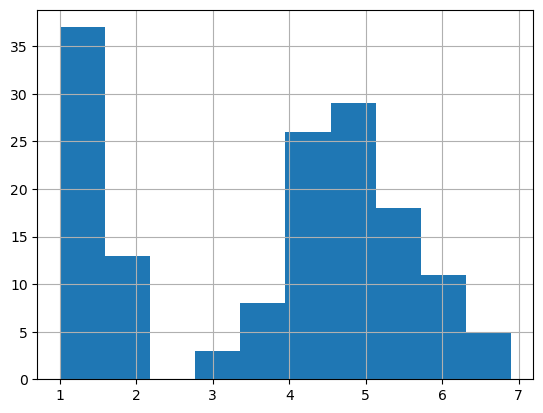

In [17]:
df['PetalLengthCm'].hist()

<Axes: >

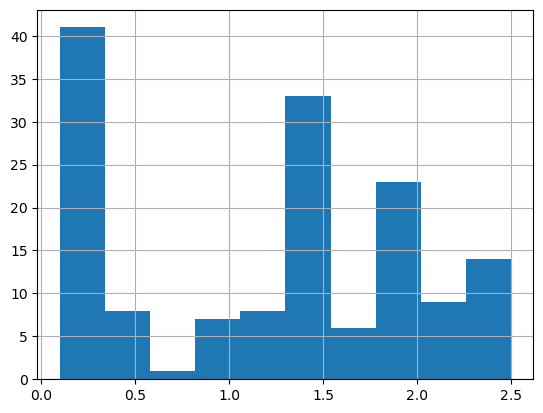

In [18]:
df['PetalWidthCm'].hist()

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [21]:
df['Species']=le.fit_transform(df['Species'])
df.sample(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
4,5.0,3.6,1.4,0.2,0
130,7.4,2.8,6.1,1.9,2
24,4.8,3.4,1.9,0.2,0
79,5.7,2.6,3.5,1.0,1
103,6.3,2.9,5.6,1.8,2
106,4.9,2.5,4.5,1.7,2
49,5.0,3.3,1.4,0.2,0
118,7.7,2.6,6.9,2.3,2
94,5.6,2.7,4.2,1.3,1
77,6.7,3.0,5.0,1.7,1


In [22]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Species'])
y=df['Species']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [26]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [32]:
print('Accuracy:',model.score(X_test,y_test)*100)

Accuracy: 100.0


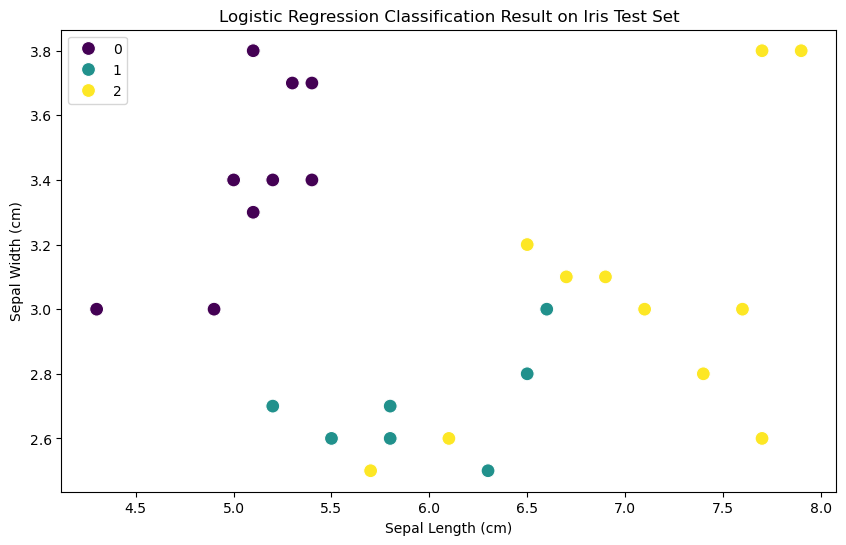

In [29]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['SepalLengthCm'], y=X_test['SepalWidthCm'], hue=y_pred, palette="viridis",s=100)
plt.title("Logistic Regression Classification Result on Iris Test Set")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()

In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average="weighted")
recall=recall_score(y_test,y_pred,average="weighted")
f1=f1_score(y_test,y_pred,average="weighted")

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
